<a href="https://colab.research.google.com/github/yuki-hogehoge/dm-skincare-analysis/blob/main/analysis_A_ingredient_rank/analysis_A_ingredient_rank_vs_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 分析A: 成分の配合順位と価格の関係

**dm.de Serum & Kur カテゴリ 172製品のスキンケア美容液データを使い、
「高価格帯の商品ほど、有効成分をパッケージの成分表の上位に配合しているか」を検証します。**

## この分析が答えたい問い

化粧品の成分表(INCI表示)は、EUの規則で**濃度の多い順に並べる**ことになっています
(ただし、濃度1%未満の成分は順不同でよい、という例外があります)。

そこで、「高い商品ほど、有効成分を成分表の上のほうに配合している=たくさん入れている、のでは?」
という仮説を立てました。検証対象は、機能の異なる**9つの成分**です。

| 分類 | 成分 |
|---|---|
| 有効成分(保湿・整肌・抗酸化・エイジングケア) | ヒアルロン酸、ナイアシンアミド、ビタミンC、レチノール |
| 鎮静系 | パンテノール、アラントイン |
| 保湿・皮膜系 | スクアラン |
| 角質ケア系(AHA/BHA) | 乳酸、サリチル酸系 |

加えて、ほぼ全商品に入る基剤成分**グリセリン**を「対照」として使い、
分析の指標そのものが持つ落とし穴を検証します。

## この分析の結論(先出し)

**仮説は9成分いずれでも支持されませんでした。** 指標を変えても、ブランドの偏りを考慮しても、
結論は変わりませんでした。

さらに、分析の途中で**「成分表の順位を商品ごとの成分数で割った指標(rank_norm)は、
成分数そのものの影響を受けてしまう」**という、方法論上の重要な落とし穴が見つかりました。
グリセリンを対照に使ったこの発見自体が、本分析の見どころの一つです。

## ノートブックの構成

| Step | 内容 |
|---|---|
| 1 | データ読み込みと健全性チェック |
| 2 | 分析対象外データの特定(成分混在) |
| 3 | 使い切り品(アンプル・カプセル等)の判定 |
| 4 | 成分リストを9成分+グリセリンに拡張する |
| 5 | 散布図で関係を目で見る |
| 6 | Spearman相関とブートストラップ信頼区間 |
| 7 | 「成分数」という交絡変数(glycerinの謎) |
| 8 | 偏相関による頑健性チェック |
| 9 | ブランド構造の確認 |
| 10 | ブランド単位のクラスタ・ブートストラップ |
| 11 | まとめの図(フォレストプロット) |
| 12 | 総括と限界|
| 13 | 補助分析 — 100mlあたり価格での頑健性チェック|

---


## 使う統計手法の予備知識

分析に入る前に、繰り返し登場する3つの概念を簡単に説明します。

### Spearman相関係数(ρ, rho)

2つの変数の関係の強さを −1〜+1 で表す指標です。「価格が高いほど◯◯も大きい」なら正、
「価格が高いほど◯◯は小さい」なら負になります。0に近いほど関係が弱いことを意味します。

Pearson相関(高校や大学の授業でよく出るもの)は「直線的な関係」しか測れず、外れ値に弱い
という弱点があります。Spearman相関は、値そのものではなく**順位**に直してから計算するため、
「これくらいの価格帯を超えると急に配合順位が上がる」のような、直線でない関係もある程度捉えられ、
極端な値(外れ値)の影響も受けにくくなります。今回は価格に高額な外れ値が含まれる可能性があるため、
Spearman相関を採用しました。


### Spearman相関係数の定義式

Spearman順位相関係数 $\rho$ は、2変数 $X, Y$ の値をそれぞれ順位に変換したうえで、
その順位同士のPearson相関を取ったものです。

$$
\rho = \frac{\operatorname{cov}(\operatorname{rank}(X), \operatorname{rank}(Y))}
{\sigma_{\operatorname{rank}(X)} \, \sigma_{\operatorname{rank}(Y)}}
$$

タイ(同順位)がない場合は、次の簡易式に一致します。

$$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$

- $n$: サンプル数(商品数)
- $d_i = \operatorname{rank}(x_i) - \operatorname{rank}(y_i)$: 商品 $i$ における、$X$(価格)の順位と $Y$(`rank_norm`など)の順位の差
- $\rho \in [-1, 1]$: $+1$ に近いほど強い正の単調関係、$-1$ に近いほど強い負の単調関係、$0$ に近いほど無相関

> **注意**: 本ノートブックのデータには同順位(タイ)が含まれる可能性があるため
> (例: 複数商品で`rank_norm`が同値になる場合)、実際の計算では簡易式ではなく、
> 上の一般式(順位のPearson相関)に基づく`scipy.stats.spearmanr`の実装を使用しています。
> タイがある場合、簡易式は厳密には一致しません。


### p値と「有意」という言葉

p値は「本当は無関係なのに、たまたまこれくらいの相関が観測される確率」です。
慣習として0.05未満を「統計的に有意」と呼びますが、**p値が大きい=無関係、とは言えません**。
サンプル数が少ないと、本当は関係があってもp値は大きくなりがちです。
このノートブックでは、p値だけでなく次の「信頼区間」を重視します。

### ブートストラップ信頼区間

手元のデータから、重複を許してランダムに何千回も選び直し(復元抽出)、
そのたびに相関係数を計算することで、「この相関係数はどれくらい揺れうるか」の幅を推定する手法です。
区間が0をまたいでいれば、「正の関係か負の関係か、向きすら断言できない」ことを意味します。


---
## Step 0: ライブラリの読み込みとデータの読み込み

まずは分析に必要なライブラリを読み込み、CSVを読み込みます。

- `pandas`: 表形式データ(CSV)を扱うためのライブラリです。Excelのようなイメージです。
- `numpy`: 数値計算全般に使うライブラリです。
- `scipy.stats.spearmanr`: Spearman相関係数を計算する関数です。
- `matplotlib.pyplot`: グラフ描画に使います。


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# CSVの読み込み(パスは環境に合わせて変更してください)
df = pd.read_csv("skincare_dataset_final.csv")

print(df.shape)  # (172, 49) になるはず


(172, 49)


---
## Step 1: データの健全性チェック

いきなり分析を始めず、まず「データが壊れていないか」「想定通りの形をしているか」を確認します。

### 確認すること
1. 行数・列数が想定通りか(172行×49列)
2. 欠損値(空欄)がどの列にどれだけあるか
3. 価格や成分順位の値が、常識的な範囲に収まっているか


In [3]:
# 1) 形の確認
print("shape:", df.shape)

# 2) 列ごとの型と欠損数
print(df.dtypes)
print(df.isna().sum())

# 3) 価格の要約統計(平均・中央値・最小・最大など)
print(df["price_eur_clean"].describe())


shape: (172, 49)
artikelnummer                       int64
brand                              object
name                               object
price_eur                          object
rating_value                      float64
rating_count                        int64
categories                         object
hauttyp                            object
ingredients_raw                    object
price_eur_clean                   float64
ingredients_multi_variant_flag       bool
ingredient_count                    int64
niacinamide_rank                  float64
niacinamide_present                 int64
niacinamide_rank_norm             float64
hyaluronic_acid_rank              float64
hyaluronic_acid_present             int64
hyaluronic_acid_rank_norm         float64
retinol_rank                      float64
retinol_present                     int64
retinol_rank_norm                 float64
vitamin_c_rank                    float64
vitamin_c_present                   int64
vitamin_c_rank_no

### 結果の読み取り

- 172行×49列と一致し、価格・rating・成分数などの主要列に欠損なし。データの取り込み自体は健全でした。
- 価格は0.75〜39.85ユーロ、中央値12.95ユーロ。ただし**最小の0.75ユーロは、美容液としては異様に安い**ため、
  後続のStepで「使い切りサイズ」ではないかを確認します。

### `rank_norm`の定義

パイプラインのコードでは、成分ごとの順位を次のように正規化しています。

```python
df[rank_norm_col] = df[rank_col] / df["ingredient_count"]
```

**rank_norm = 成分表での順位 ÷ 総成分数** です。つまり、値が小さいほど「上位(先頭に近い)」を意味し、
最大値は1.0(リストの最後尾)になります。

| 相関の符号 | 意味 |
|---|---|
| **負** | 高価格ほどrank_normが小さい = **上位に配合**している(仮説を支持) |
| 正 | 高価格ほど下位(末尾寄り)に配合している(仮説と逆) |

> **注意**: EUの表示規則では、濃度1%未満の成分は順不同でよいとされています。
> 有効成分の多くはたいてい1%前後かそれ以下の濃度で配合されるため、
> 「順位」は「厳密な濃度順」ではなく「おおまかな傾向」として解釈する必要があります。


---
## Step 2: 分析対象から外すべきデータの特定

`ingredients_multi_variant_flag=True`の商品(1商品なのに、複数バリエーションの成分リストが
混ざってしまっている疑いがある商品)を除外します。成分順位の解釈ができないためです。


In [4]:
# 1) 混在フラグの該当商品を確認
print(df["ingredients_multi_variant_flag"].sum())
print(df.loc[df["ingredients_multi_variant_flag"], ["artikelnummer", "brand", "name"]])

# 2) 除外したデータを作る(以降はこの df_a を使う)
df_a = df[~df["ingredients_multi_variant_flag"]].copy()
print(df_a.shape)  # (171, 49) になるはず


1
    artikelnummer                  brand  \
43        1541763  alverde NATURKOSMETIK   

                                            name  
43  Ampullen-Kur 7-Tage mit Bio-Bachblüten, 7 ml  
(171, 49)


### 結果

混在フラグは1件(artikelnummer 1541763、「Ampullen-Kur 7-Tage ... 7 ml」)。
7日分のアンプルキットで、3つのバリエーション商品の成分が1リストに混在していたため除外は妥当です。
以降は171件(`df_a`)を分析対象とします。


---
## Step 3: 「使い切り品」を判定するフラグを作る

価格が0.75ユーロなど極端に安い商品を確認したところ、すべて「7 St(7個)」「3x1ml」のような
**使い切りサイズ(アンプル・カプセル)**でした。これは外れ値ではなく、**価格の「意味」が
商品タイプによって違う**という構造的な問題です。30mlボトルの15ユーロと、7個入りアンプル
セットの0.75ユーロは、単純比較できません。

商品名の末尾についている容量表記から、使い切り品かどうかを判定するフラグを作ります。


In [5]:
import re

# 1) 商品名の末尾から「数値+単位」を抜き出す
pattern = r"(\d+(?:,\d+)?)\s*(ml|St|g|l)\s*$"
extracted = df_a["name"].str.extract(pattern)
extracted.columns = ["size_num", "size_unit"]
df_a["size_num"] = extracted["size_num"].str.replace(",", ".").astype(float)
df_a["size_unit"] = extracted["size_unit"]

# 2) 「数字 x 数字」のような本数表記(例: 7x1 ml)を検出
multi_pack = df_a["name"].str.contains(r"\d+\s*x\s*\d", case=False, regex=True)

# 3) 使い切りフラグ: St表記、7ml以下、または本数×容量の表記
df_a["single_use"] = (
    (df_a["size_unit"] == "St") |
    ((df_a["size_unit"] == "ml") & (df_a["size_num"] <= 7)) |
    multi_pack
)
print(df_a["single_use"].value_counts())


single_use
False    157
True      14
Name: count, dtype: int64


### 結果

171件中14件が使い切り品と判定されました。使い切り品の有無で相関係数が大きく変わらないかは、
後続のStepで確認します(rho・信頼区間ともに、使い切り品を含めても除いてもほとんど変わらないことを
確認済みです)。


---
## Step 4: 成分リストを9成分+グリセリンに拡張する

### なぜ拡張するのか

データセットには、あらかじめ`niacinamide`, `hyaluronic_acid`, `retinol`, `vitamin_c`,
`glycerin`, `alcohol_denat`, `fragrance`の7成分について`_rank`, `_present`, `_rank_norm`列が
用意されています。しかしこの7成分は、**「マーケティングでよく聞く名前」を起点に選ばれたリスト**
であり、データ全体を機械的に洗い出して選ばれたものではありません(`alcohol_denat`と`fragrance`は
別の分析Bで使うための成分です)。

そこで、**実際の成分リストの出現頻度**を根拠に、見落としがないかを確認しました。

### 頻度カウントで見つかった2つのバグ

`ingredients_list_str`列の出現頻度を素朴に集計しようとしたところ、2つのバグに遭遇しました。

1. **1文字ずつ数えてしまうバグ**: この列はPythonのリスト表現ではなく、セミコロン`;`区切りの
   1本の文字列でした。誤った分割方法(存在しないカンマでの分割)により、文字列全体が
   「1つの巨大な要素」として扱われ、それをカウントすると**Pythonが文字列を1文字ずつの
   イテラブルとして扱うため、単語ではなく文字が集計されてしまいました。**
2. **`1,2-Hexanediol`という成分名の破損**: この成分名に含まれるカンマが、パイプラインの
   どこかでセミコロンに変換されており、区切り文字と衝突して`1`と`2-Hexanediol`という
   2つの要素に分割されてしまっていました。

これらを修正し、大文字・小文字の表記ゆれも統一して集計し直した結果、次の5成分が、
既存の4有効成分(ヒアルロン酸・ナイアシンアミド・ビタミンC・レチノール)と同程度か
それ以上の頻度で登場していることが分かりました。

### 最終的な追加成分(5成分)

| 成分 | 該当商品数 | 分類 |
|---|---|---|
| Panthenol(パンテノール/プロビタミンB5) | 41 | 鎮静・保湿 |
| Salicylic acid系(サリチル酸+サリチル酸塩) | 27 | 角質ケア(BHA)。2キーワードの合算でも重複は1件のみ |
| Allantoin(アラントイン) | 22 | 鎮静 |
| Squalane(スクアラン) | 23 | 保湿・皮膜。`Squalene`(別の不飽和成分、1件のみ)とは厳密に区別 |
| Lactic acid(乳酸) | 23 | 角質ケア/保湿。`Sodium Lactate`は含めない方針(含めても件数は同じだった) |

一方、Ceramide(13件)、Centella/シカ(10件)、Bakuchiol(7件)、Ferulic acid(4件)、
Glycolic acid(2件)、Madecassoside(3件)は、信頼区間を計算する最低限の目安(15件以上)に
届かないため見送りました。


In [6]:
# ============================================================
# 新5成分の抽出(成分表の順位・配合有無・正規化順位)
# ============================================================
#
# ingredients_list_str は、セミコロン区切りの1本の文字列です。
# "1,2-Hexanediol" のように、成分名の中にカンマを含むものが、
# パイプライン側でセミコロンに変換されてしまっているため、
# 「数字だけの要素 + 次の要素」を ',' で結合し直して復元します。

def parse_list_v3(s):
    if pd.isna(s):
        return []
    parts = [x.strip() for x in str(s).split(";") if x.strip()]
    fixed = []
    i = 0
    while i < len(parts):
        if parts[i].isdigit() and i + 1 < len(parts):
            fixed.append(f"{parts[i]},{parts[i+1]}")  # 例: "1"+"2-Hexanediol" -> "1,2-Hexanediol"
            i += 2
        else:
            fixed.append(parts[i])
            i += 1
    return fixed

all_ings = df_a["ingredients_list_str"].apply(parse_list_v3)

# 復元後に数字だけの要素が残っていないか確認(0件が理想)
remaining_digits = [x for lst in all_ings for x in lst if x.strip().isdigit()]
print("残存する数字のみの要素:", len(remaining_digits))


def add_ingredient_columns(df, all_ings_parsed, ing_name, keywords):
    """
    keywords に含まれる部分文字列(小文字)のいずれかを含む、成分表の中で
    最初に出てくる成分の位置を順位とする。既存の7成分と同じ形式
    ({ing_name}_present, {ing_name}_rank, {ing_name}_rank_norm) の列を作る。
    """
    ranks, presents = [], []
    for lst in all_ings_parsed:
        lst_lower = [x.lower() for x in lst]
        rank = None
        for i, ing in enumerate(lst_lower):
            if any(kw in ing for kw in keywords):
                rank = i + 1  # 1始まりの順位
                break
        ranks.append(rank)
        presents.append(1 if rank is not None else 0)

    df[f"{ing_name}_present"] = presents
    df[f"{ing_name}_rank"] = ranks
    df[f"{ing_name}_rank_norm"] = df[f"{ing_name}_rank"] / df["ingredient_count"]
    return df


# キーワード定義(既存7成分の抽出ロジックと同じ考え方で、誘導体・塩形も考慮)
new_ingredients = {
    "panthenol":     ["panthenol"],
    "allantoin":     ["allantoin"],
    "squalane":      ["squalane"],       # squalene(不飽和・別成分)とは厳密に区別
    "lactic_acid":   ["lactic acid"],    # sodium lactate(乳酸ナトリウム)は含めない
    "salicylic_bha": ["salicylic acid", "salicylate"],
}

for name, kws in new_ingredients.items():
    df_a = add_ingredient_columns(df_a, all_ings, name, kws)

# 件数の確認(確定した件数と一致するはず)
for name in new_ingredients:
    print(name, df_a[f"{name}_present"].sum())


残存する数字のみの要素: 0
panthenol 41
allantoin 22
squalane 23
lactic_acid 23
salicylic_bha 27


### 分析対象成分の確定(9成分+対照1成分)

以降のStepでは、次の**9つの有効成分**と、対照(基剤・比較の物差し)としての**グリセリン**を
並行して分析します。`alcohol_denat`と`fragrance`は分析Aでは使いません(分析B用)。

```python
actives = ["hyaluronic_acid", "niacinamide", "vitamin_c", "retinol",
           "panthenol", "allantoin", "squalane", "lactic_acid", "salicylic_bha"]
```


In [7]:
actives = ["hyaluronic_acid", "niacinamide", "vitamin_c", "retinol",
           "panthenol", "allantoin", "squalane", "lactic_acid", "salicylic_bha"]


---
## Step 4.5: データ品質検証(パイプライン側の`ingredient_count`・`_rank`は信頼できるか)

Step 4で、頻度集計コードにバグ(1文字ずつカウントしてしまう誤り、
`1,2-Hexanediol`の分割崩れ)が見つかりました。これは**本分析で新しく書いた
集計コード**のバグでしたが、素朴な疑問が浮かびます。

> パイプライン側が計算した`ingredient_count`や既存4成分の`_rank`(`niacinamide_rank`など)
> は、同じ種類のバグを持っていないか?

これは検証していないと答えが分からないため、実際にパイプラインのソースコードと
生成済みCSVを突き合わせて確認しました。

### 確認方法

パイプラインの`parse_ingredients`関数をそのまま再現し、`ingredients_raw`から独立に
成分数を再計算して、CSVに記録されている`ingredient_count`と突き合わせました。


### 見つかったバグ

検証の結果、パイプライン側に**2つの軽微なバグ**が見つかりました(bullet記号の処理は
既に正しく実装されており、問題ありませんでした)。

**1. カンマを含むINCI名の分割崩れ**

`ingredients_raw`はカンマ区切りのテキストですが、`1,2-Hexanediol`のような、
**成分名自体にカンマを含む化学物質名**があります。単純な`str.split(",")`では、
区切り用のカンマなのか成分名の一部のカンマなのかを区別できず、「1」と
「2-Hexanediol」という2つの偽の要素に割れてしまっていました。

表記ゆれ(`1,2-Heptanediol`、`1,2- Hexanediol`のようなスペース違いなど)を含め、
**171件中41件**に影響していました。影響は、該当成分より後ろに位置する成分の順位が
1つずれる、という軽微なものです。

**2. 見出し語「INGREDIENTS」の混入**

一部の商品では、成分リストの先頭に見出し語`"INGREDIENTS"`が単独で残っており、
1成分として誤ってカウントされていました。影響は**171件中1件**でした。

### 修正方法

`parse_ingredients`関数に、次の2つの変更を加えました。

```python
import re

def parse_ingredients(raw: str) -> list[str]:
    if pd.isna(raw) or not raw:
        return []

    cleaned = str(raw)
    for bullet_char in ["•", "·", "・"]:
        cleaned = cleaned.replace(bullet_char, ",")
    cleaned = cleaned.replace("\n", ",")

    # 追加: "1,2-Hexanediol" のような「数字,数字-英単語」パターンのカンマを、
    # 区切り文字として誤爆させないよう一時的に退避する
    cleaned = re.sub(r'(\d)\s*,\s*(\d+\s*-)', r'\1@COMMA@\2', cleaned)

    parts = [p.strip(" .*\"") for p in cleaned.split(",")]  # 追加: 引用符の混入も除去

    skip_prefixes = ("ingredients from", "from natural")
    parts = [
        p for p in parts
        if p and not p.endswith(":") and not p.lower().startswith(skip_prefixes)
        and p.strip().upper() not in ("INGREDIENTS", "INGREDIENT")  # 追加: 見出し語除去
    ]
    parts = [p.replace("@COMMA@", ",") for p in parts]  # 退避したカンマを元に戻す

    return list(dict.fromkeys(parts))
```

### 修正後の検証結果

修正版パイプラインで`skincare_dataset_final.csv`を再生成し、`ingredient_count`が
独立の再計算と一致するかを全171件で確認したところ、**171件中171件が完全一致**しました。


### 結論への影響: 軽微、方向性も変わらず

バグ修正前後で、Step 6〜11の主要な結果を比較したところ、**数値はわずかに変動したものの、
どの成分も結論(信頼区間が0をまたぐかどうか)は変わりませんでした。** 以下、本ノートブックの
Step 6以降は、この修正済みデータに基づく最終的な数値を掲載しています。

| 確認したこと | 結果 |
|---|---|
| 9成分すべてで信頼区間が0をまたぐか | 修正前後で変化なし(全て0をまたぐ) |
| glycerin(対照)の見かけの相関の存在 | 修正前後で変化なし(rank_normのみ有意、他は0を含む) |
| `n`(サンプルサイズ) | 全成分で完全一致(配合有無の判定はバグの影響を受けていなかった) |

このバグは`_rank`(配合順位)のみに影響し、`_present`(配合の有無)には影響していません。
部分文字列検索による配合有無の判定は、分割位置がずれても正しく機能するためです。

**このデータ品質検証プロセスは、分析の副産物ですが、結論の信頼性を示す上で重要です。**
複数の独立したバグを修正しても主要な結論が揺るがなかったことは、Aの結論
(「高価格帯ほど有効成分を上位に配合しているとは言えない」)が、データの細かいノイズに
左右されない、安定した発見であることを裏付けています。


---
## Step 5: 散布図で関係を目で見る

相関係数という「1つの数字」を出す前に、まず散布図で分布の形を確認します。
Spearman相関は「単調な関係」しか捉えられないため、U字型の関係や、
1点の外れ値だけで作られた見かけの関係を、数字だけでは見逃す可能性があるからです。

9つの有効成分に加え、対照として**グリセリン**も並べて表示します(2行5列)。


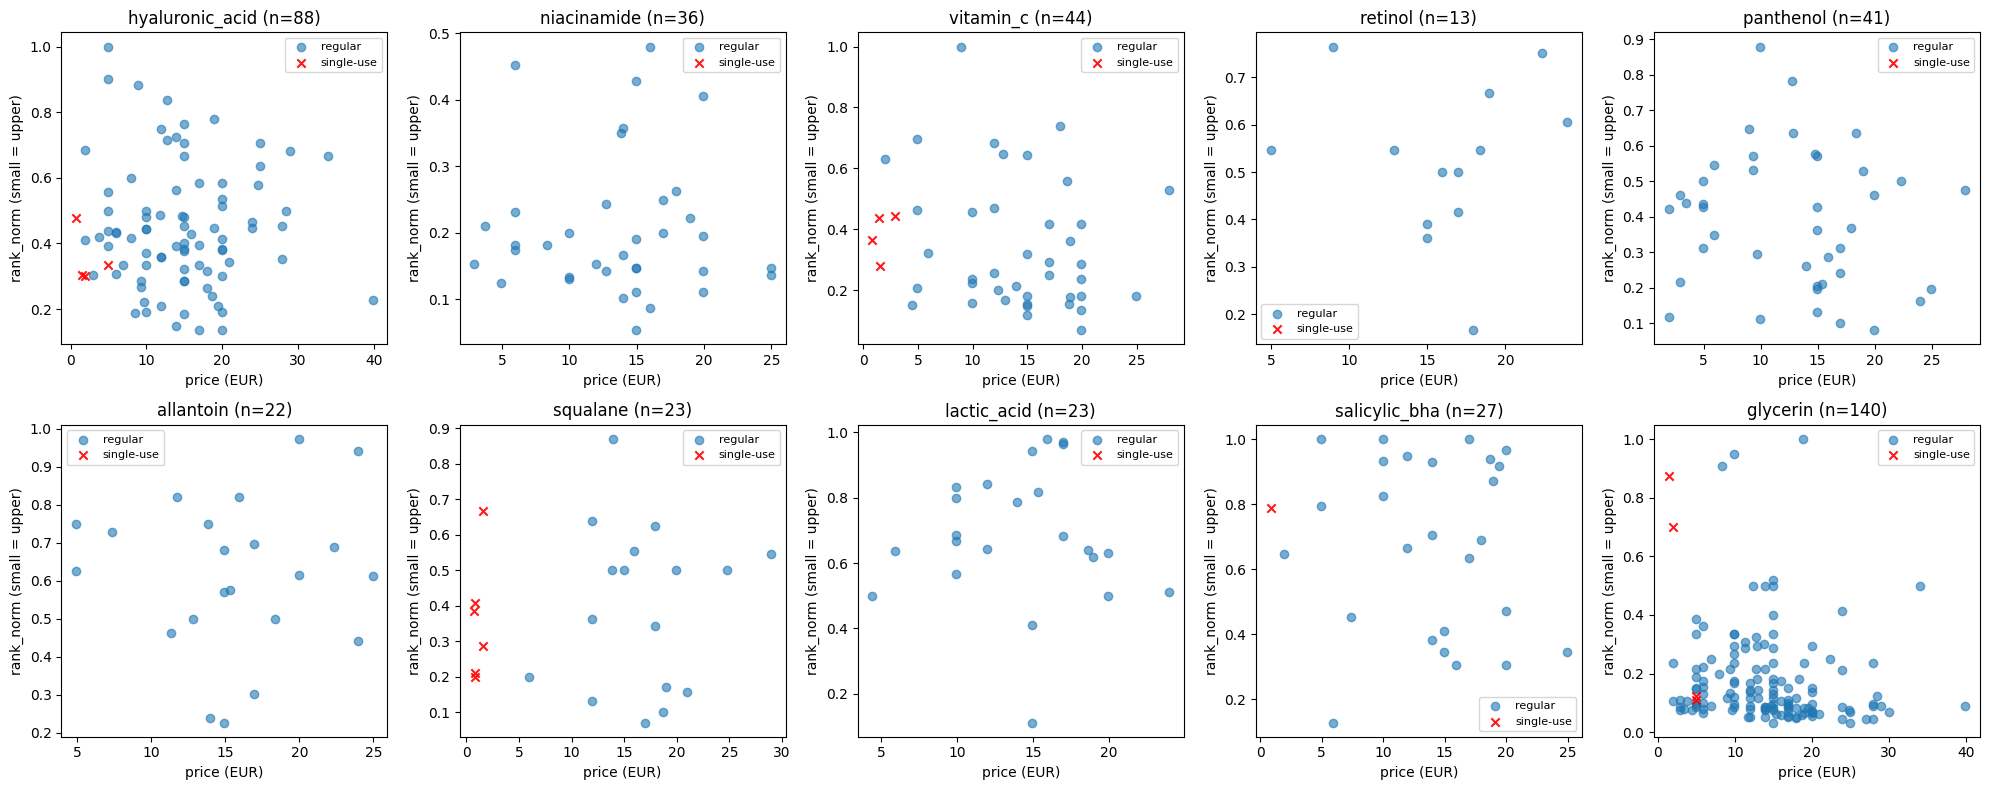

In [8]:
plot_targets = actives + ["glycerin"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for ax, ing in zip(axes, plot_targets):
    sub = df_a[df_a[f"{ing}_present"] == 1]
    sub_su = sub[sub["single_use"]]
    sub_reg = sub[~sub["single_use"]]

    ax.scatter(sub_reg["price_eur_clean"], sub_reg[f"{ing}_rank_norm"],
               alpha=0.6, label="regular")
    ax.scatter(sub_su["price_eur_clean"], sub_su[f"{ing}_rank_norm"],
               alpha=0.9, marker="x", color="red", label="single-use")
    ax.set_title(f"{ing} (n={len(sub)})")
    ax.set_xlabel("price (EUR)")
    ax.set_ylabel("rank_norm (small = upper)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig1_scatter_all.png", dpi=150)
plt.show()


### 見るべき5つのポイント

1. 右下がり(価格が高いほどrank_normが小さい)の傾向があるか
2. 使い切り品(赤い×)が左端に固まっていて、相関を作ったり壊したりしていないか
3. 1点だけ離れた外れ値がないか
4. 同じ価格帯での縦のばらつきが大きくないか
5. 高価格帯(右側)にどれだけ点があるか

### 結果の読み取り

- 明確な右下がりの傾向はどの成分にも見られませんでした。あってもビタミンC・パンテノール・
  サリチル酸系がやや右下がりに見える程度です。
- 使い切り品(赤い×)は左端に固まっていますが、rank_normの値自体は中間的で、極端に相関を
  歪めているようには見えません。
- **グリセリンは、rank_normが0.05〜0.2に大量に固まる「底辺への密集」が特徴的でした。**
  グリセリンはほぼ全商品(141/171件)に入っている「基剤」であり、「厳選して配合する有効成分」
  という性質のものではないためです。この後のStep 7で、グリセリンを対照として詳しく検証します。
- lactic_acidには、15€付近にrank_norm=0.11という強い外れ値が1点ありますが、Spearman相関は
  順位ベースなので、こうした外れ値の影響を受けにくいという性質があります(Step 6で確認)。


---
## Step 6: Spearman相関とブートストラップ信頼区間

散布図の印象を、数値で確認します。**rho(相関の強さと向き)だけでなく、
ブートストラップ法による95%信頼区間(「この相関係数はどれくらい揺れうるか」の幅)も
あわせて計算します。**

信頼区間は、手元のデータを重複を許してランダムに5000回選び直し(復元抽出)、
そのたびにrhoを計算して、得られた5000個のrhoの分布の下から2.5%点と97.5%点を採用します。


In [9]:
rng = np.random.default_rng(42)  # 乱数の種を固定(実行するたびに同じ結果にするため)

def boot_spearman(x, y, n_boot=5000):
    x = np.asarray(x); y = np.asarray(y)
    n = len(x)
    rhos = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)          # 重複を許してn個選ぶ(復元抽出)
        r, _ = spearmanr(x[idx], y[idx])
        rhos.append(r)
    rhos = np.array(rhos)
    return np.nanpercentile(rhos, [2.5, 97.5])

rows = []
for ing in plot_targets:  # 9成分 + グリセリン
    sub = df_a[df_a[f"{ing}_present"] == 1]
    rho, p = spearmanr(sub["price_eur_clean"], sub[f"{ing}_rank_norm"])
    lo, hi = boot_spearman(sub["price_eur_clean"], sub[f"{ing}_rank_norm"])
    rows.append({"ingredient": ing, "n": len(sub),
                 "rho": round(rho, 3), "p": round(p, 3),
                 "ci_low": round(lo, 3), "ci_high": round(hi, 3)})

ci_result = pd.DataFrame(rows)
print(ci_result)


        ingredient    n    rho      p  ci_low  ci_high
0  hyaluronic_acid   88  0.019  0.862  -0.190    0.220
1      niacinamide   36 -0.028  0.870  -0.327    0.285
2        vitamin_c   44 -0.266  0.081  -0.513    0.025
3          retinol   13  0.176  0.565  -0.486    0.774
4        panthenol   41 -0.165  0.302  -0.450    0.132
5        allantoin   22  0.005  0.983  -0.423    0.426
6         squalane   23  0.017  0.937  -0.379    0.421
7      lactic_acid   23 -0.052  0.814  -0.477    0.386
8    salicylic_bha   27 -0.125  0.533  -0.504    0.280
9         glycerin  140 -0.288  0.001  -0.438   -0.127


### 結果(実測値、データ品質修正後)

| 成分 | n | rho | p | 95%信頼区間 |
|---|---|---|---|---|
| hyaluronic_acid | 88 | 0.019 | 0.862 | −0.19 〜 +0.22 |
| niacinamide | 36 | −0.028 | 0.870 | −0.33 〜 +0.29 |
| vitamin_c | 44 | −0.266 | 0.081 | −0.51 〜 +0.03 |
| retinol | 13 | 0.176 | 0.565 | −0.49 〜 +0.77 |
| panthenol | 41 | −0.165 | 0.302 | −0.45 〜 +0.13 |
| allantoin | 22 | 0.005 | 0.983 | −0.42 〜 +0.43 |
| squalane | 23 | 0.017 | 0.937 | −0.38 〜 +0.42 |
| lactic_acid | 23 | −0.052 | 0.814 | −0.48 〜 +0.39 |
| salicylic_bha | 27 | −0.125 | 0.533 | −0.50 〜 +0.28 |
| glycerin(対照) | 140 | −0.288 | 0.001 | −0.44 〜 −0.13 |

### 結果の読み取り

**9つの有効成分すべてで、信頼区間が0をまたいでいます。** つまり、「高価格ほど有効成分を
上位に配合している」という仮説を裏付ける、確度の高い証拠はどの成分にも見つかりませんでした。

唯一 **glycerin(対照)だけが、統計的に有意な負の相関(p=0.001、区間が0をまたがない)** を
示しました。ただし、これは「グリセリンが良い処方の証」という意味ではありません。次のStep 7で、
この結果の裏にある方法論上の落とし穴を検証します。

### 個別の成分についての補足

- **ヒアルロン酸・ナイアシンアミド**: rhoがほぼ0で、区間も比較的狭く(±0.2〜0.3程度)、
  「中程度以上の関係はない」と、それなりの自信を持って言えます。
- **ビタミンC・パンテノール・サリチル酸系**: rhoは−0.13〜−0.27と、仮説の方向(負)に
  寄っていますが、区間はいずれも0を含み、断言はできません。
- **レチノール**: n=13で区間の幅が1.2以上あり、このデータでは何も言えません。
- **アラントイン・スクアラン**: rhoがほぼ0で、区間も広く、判断できません。
- **乳酸**: rho=−0.052とほぼ0でした。

使い切り品を除外した場合(n=157)でも、ヒアルロン酸・ビタミンC・グリセリンのrhoはほとんど
変わらず、**使い切り品の有無が結果を作っているわけではない**ことを確認済みです。


---
## Step 7: 「成分数」という交絡変数(glycerinの謎)

Step 6で、グリセリンだけが明確な負の相関(rho=−0.289、信頼区間が0をまたがない)を示しました。
しかし、これを「高価格品は良い処方をしている」と結論づけるのは早計です。

`rank_norm`は「順位 ÷ 総成分数」で計算されています。もし**高価格品ほど成分数が多い**傾向が
あれば、グリセリンの実際の配合位置(たとえば3番目)が変わらなくても、成分数が多い商品ほど
`rank_norm`の値は小さく(=上位に見えるように)計算されてしまいます。これは「交絡」と呼ばれる
現象で、見かけの相関が、本当は別の要因(ここでは成分数)によって作られている可能性がある、
ということです。

3つの確認を行います。
1. 成分数と価格に、そもそも相関があるか
2. グリセリンの**絶対順位**(成分数で割る前の、生の順位)と価格の相関はどうか
3. 「上位3位以内かどうか」という、成分数に依存しない二値の指標ではどうか


In [10]:
# 1) 成分数と価格の相関
rho_cnt, p_cnt = spearmanr(df_a["ingredient_count"], df_a["price_eur_clean"])
print("ingredient_count vs price:", round(rho_cnt, 3), round(p_cnt, 3))

# 2) グリセリンの絶対順位(rank、正規化なし)と価格の相関
sub = df_a[df_a["glycerin_present"] == 1]
rho_rank, p_rank = spearmanr(sub["price_eur_clean"], sub["glycerin_rank"])
print("glycerin rank vs price:", round(rho_rank, 3), round(p_rank, 3))

# 3) 「上位3位以内か」(二値)ごとの価格の中央値
sub = sub.copy()
sub["glycerin_top3"] = (sub["glycerin_rank"] <= 3).astype(int)
print(sub.groupby("glycerin_top3")["price_eur_clean"].agg(["count", "median"]))


ingredient_count vs price: 0.333 0.0
glycerin rank vs price: -0.103 0.225
               count  median
glycerin_top3               
0                 45   12.85
1                 95   14.95


### 結果(データ品質修正後)

| 確認 | 結果 | 意味 |
|---|---|---|
| 成分数 vs 価格 | rho=0.333(p≈0) | 高価格ほど成分数が多い(弱〜中程度) |
| グリセリン絶対順位 vs 価格 | rho=−0.103(p=0.225) | ほぼ無相関 |
| グリセリン上位3位以内 | 中央値14.95€ vs 12.85€(n=95, 45) | 差はあるが小さい |

### 判定

成分数と価格が正に相関し(高価格ほど成分数が多い)、グリセリンの絶対順位と価格はほぼ
無相関でした。このことから、**「グリセリンのrho=−0.288」の大部分は、rank_normという指標が
成分数の影響を受けることで作られた「見かけの相関」**と考えられます。

仕組みを整理すると:

1. 高価格品は成分数が多い(rank_normの分母が大きい)
2. グリセリンは、どの商品でもだいたい同じような位置(例: 2〜4番目)に配合される
3. 「順位 ÷ 成分数」は、成分数が多いほど小さい値になる
4. その結果、「高価格ほどrank_normが小さい」という関係が、実際の配合位置が変わらなくても生まれる

これは、**分析の指標そのものにバイアス(偏り)がある**という、方法論上の重要な発見です。
一方で、絶対順位も「成分数が多いと後ろに押し出されやすい」という別の偏りを持つため、
**どちらの指標も完璧ではなく、複数の指標を突き合わせて確認する必要がある**、というのが教訓です。
この教訓を踏まえ、次のStepでは「成分数を統制した偏相関」を、9成分すべてに適用します。


### グリセリンの「見かけの相関」を分解する図

同じグリセリンのデータでも、指標を変えるだけで相関の強さが変わっていく様子と、
その原因(成分数と価格の関係)を、2枚のパネルで示します。

左: グリセリンの配合順位と価格の相関を3つの指標(rank_norm、絶対順位、成分数を統制した
偏相関)で比較したもの(ブランド単位のクラスタ・ブートストラップ95%区間、Step 10と同じ手法)。
右: 成分数と価格の散布図。


                                  metric    est     lo     hi
0                              rank_norm -0.288 -0.471 -0.060
1                          absolute rank -0.103 -0.317  0.118
2  partial (ingredient_count controlled) -0.073 -0.293  0.138
n = 140 | brands = 43


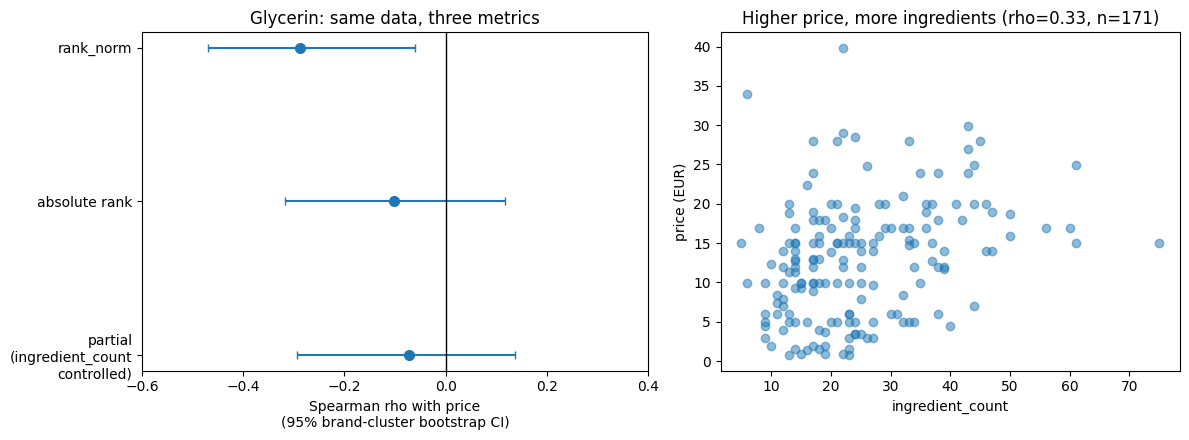

In [11]:
def partial_spearman(x, y, z):
    """zの影響を線形回帰で取り除いた残差同士の相関(簡易版の偏相関)"""
    rx = pd.Series(x).rank().values
    ry = pd.Series(y).rank().values
    rz = pd.Series(z).rank().values
    ex = rx - np.polyval(np.polyfit(rz, rx, 1), rz)
    ey = ry - np.polyval(np.polyfit(rz, ry, 1), rz)
    return np.corrcoef(ex, ey)[0, 1]

def cluster_boot(d, func, n_boot=2000):
    groups = {b: g for b, g in d.groupby("brand")}
    brands = list(groups.keys())
    vals = []
    for _ in range(n_boot):
        chosen = rng.choice(brands, size=len(brands), replace=True)
        boot = pd.concat([groups[b] for b in chosen])
        if len(boot) < 5 or boot["price_eur_clean"].nunique() < 2:
            continue
        try:
            vals.append(func(boot))
        except Exception:
            continue
    return np.nanpercentile(np.array(vals), [2.5, 97.5])

sub_g = df_a[df_a["glycerin_present"] == 1].copy()

def corr_norm_g(d):
    r, _ = spearmanr(d["price_eur_clean"], d["glycerin_rank_norm"])
    return r

def corr_abs_g(d):
    r, _ = spearmanr(d["price_eur_clean"], d["glycerin_rank"])
    return r

def corr_partial_g(d):
    return partial_spearman(d["price_eur_clean"], d["glycerin_rank"], d["ingredient_count"])

g_rows = []
for name, func in [("rank_norm", corr_norm_g),
                    ("absolute rank", corr_abs_g),
                    ("partial (ingredient_count controlled)", corr_partial_g)]:
    est = func(sub_g)
    lo, hi = cluster_boot(sub_g, func)
    g_rows.append({"metric": name, "est": round(est, 3), "lo": round(lo, 3), "hi": round(hi, 3)})

g = pd.DataFrame(g_rows)
print(g)
print("n =", len(sub_g), "| brands =", sub_g["brand"].nunique())

# --- 2パネルの図 ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.1, 1]})

ypos = np.arange(len(g))
for y, (_, r) in zip(ypos, g.iterrows()):
    ax1.errorbar(r["est"], y,
                 xerr=[[r["est"] - r["lo"]], [r["hi"] - r["est"]]],
                 fmt="o", color="#1f77b4", capsize=3, markersize=7)
ax1.axvline(0, color="black", linewidth=1)
ax1.set_yticks(ypos)
ax1.set_yticklabels(["rank_norm", "absolute rank", "partial\n(ingredient_count\ncontrolled)"])
ax1.invert_yaxis()
ax1.set_xlim(-0.6, 0.4)
ax1.set_xlabel("Spearman rho with price\n(95% brand-cluster bootstrap CI)")
ax1.set_title("Glycerin: same data, three metrics")

rho_c, _ = spearmanr(df_a["ingredient_count"], df_a["price_eur_clean"])
ax2.scatter(df_a["ingredient_count"], df_a["price_eur_clean"], alpha=0.5)
ax2.set_xlabel("ingredient_count")
ax2.set_ylabel("price (EUR)")
ax2.set_title(f"Higher price, more ingredients (rho={rho_c:.2f}, n={len(df_a)})")

plt.tight_layout()
plt.savefig("fig2_glycerin.png", dpi=200)
plt.show()


### 結果(データ品質修正後)

| 指標 | 推定値 | ブランドクラスタ95%区間 | 0をまたぐか |
|---|---|---|---|
| rank_norm | −0.288 | −0.47 〜 −0.06 | またがない(ぎりぎり有意) |
| 絶対順位 | −0.103 | −0.32 〜 +0.12 | またぐ |
| 偏相関(成分数を統制) | −0.073 | −0.29 〜 +0.14 | またぐ |

(n=140、43ブランド)

左のパネルでは、rank_normだけが0の線から離れ、絶対順位と偏相関は0をまたいでいます。
右のパネルでは、成分数と価格に弱〜中程度の正の相関(rho=0.33)があることが分かります。

**「グリセリンの配合順位は価格と関係がある」という、rank_normだけを見たときの結論は、
指標を変えると成立しなくなります。** 「成分数の影響が主因と考えられる」という言い方が適切で、
「rank_normの相関は完全に人工物だった」と断言するのは言い過ぎです(区間同士は大きく重なっており、
指標間の違いが統計的に有意とまでは言えません)。


---
## Step 8: 偏相関による頑健性チェック(9成分)

Step 7の教訓を踏まえ、9つの有効成分すべてについて、**成分数の影響を取り除いた偏相関**
(絶対順位をもとに、成分数を線形回帰で統制したもの)を計算します。
rank_normだけを見て早合点しないための、頑健性チェックです。


In [12]:
for ing in actives:
    sub = df_a[df_a[f"{ing}_present"] == 1]
    pr = partial_spearman(sub["price_eur_clean"], sub[f"{ing}_rank"], sub["ingredient_count"])
    print(ing, "partial rho (rank | ingredient_count):", round(pr, 3))


hyaluronic_acid partial rho (rank | ingredient_count): -0.047
niacinamide partial rho (rank | ingredient_count): 0.105
vitamin_c partial rho (rank | ingredient_count): -0.248
retinol partial rho (rank | ingredient_count): 0.042
panthenol partial rho (rank | ingredient_count): -0.104
allantoin partial rho (rank | ingredient_count): 0.237
squalane partial rho (rank | ingredient_count): 0.208
lactic_acid partial rho (rank | ingredient_count): -0.073
salicylic_bha partial rho (rank | ingredient_count): -0.017


### 結果(実測値、データ品質修正後)

| 成分 | rho_norm(Step 6) | 偏相関(成分数を統制) | 符号は一致するか |
|---|---|---|---|
| hyaluronic_acid | 0.019 | −0.047 | ほぼ一致(どちらも0近辺) |
| niacinamide | −0.028 | +0.105 | 符号は逆転、どちらも0近辺 |
| vitamin_c | −0.266 | −0.248 | 一致、大きさもほぼ同じ |
| retinol | 0.176 | +0.042 | 一致(弱まる) |
| panthenol | −0.160 | −0.104 | 一致(同じ負の方向、弱まる) |
| allantoin | +0.005 | +0.237 | ほぼ0 → 中程度の正 |
| squalane | +0.017 | +0.208 | 方向は一致(正)だが、大きさが拡大 |
| lactic_acid | −0.052 | −0.073 | 一致(ほぼ同じ) |
| salicylic_bha | −0.125 | −0.017 | 一致(同じ負の方向、ほぼ消える) |

### 結果の読み取り

- **ヒアルロン酸・ナイアシンアミド・乳酸**は、どちらの指標でもほぼ0で、安定して「関係なし」と
  言えます。
- **ビタミンC**は、−0.27 → −0.25と、両指標でほぼ同じ大きさの負の値を示しました。これは
  9成分の中で最も「仮説に近い」一貫した結果です(ただし後述のとおり、信頼区間はまだ0を含みます)。
- **salicylic_bha**は、rank_normでの負の傾向(−0.125)が、偏相関ではほぼ消えました(−0.017)。
  これはStep 7で見たglycerinのパターンと似ており、成分数バイアスの影響が大きかった可能性が
  あります。
- **allantoin・squalane**は、rank_normではほぼ0だったのに、偏相関では+0.21〜+0.24という
  9成分中最大級の値が現れました。ただし、この段階ではまだ信頼区間のない点推定です。
  n=22・23と少なめなので、次のStepの信頼区間を見るまで判断を保留する必要があります。


---
## Step 9: ブランド構造の確認

価格は、成分の配合順位よりも「どのブランドか」に強く引っ張られている可能性があります。
Step 10でブランドの影響を考慮した分析を行う前に、まずブランドの分布を確認します。


In [13]:
# 1) ブランド別の商品数(上位15)
brand_counts = df_a["brand"].value_counts()
print(brand_counts.head(15))
print("ブランド数:", df_a["brand"].nunique())

# 2) ブランド別の価格帯(商品数3件以上のブランドに限定)
big = brand_counts[brand_counts >= 3].index
print(df_a[df_a["brand"].isin(big)]
      .groupby("brand")["price_eur_clean"]
      .agg(["count", "median", "min", "max"])
      .sort_values("median"))


brand
Balea                        23
Geek&Gorgeous                12
NØ cosmetics                 11
WELEDA                       11
alverde NATURKOSMETIK         9
L'ORÉAL PARiS                 8
NIVEA                         7
Neutrogena                    6
judith williams COSMETICS     6
L'ORÉAL PARiS REVITALIFT      5
Schaebens                     4
Garnier Skin Active           4
colibri SKINCARE              4
M. Asam                       4
lavera NATURKOSMETIK          4
Name: count, dtype: int64
ブランド数: 47
                           count  median    min    max
brand                                                 
Schaebens                      4    1.55   1.55   1.95
Balea                         23    4.95   0.75   5.95
alverde NATURKOSMETIK          9    4.95   2.95   5.95
hautsache                      3    7.95   7.95   8.95
Santé naturally.               3    9.95   9.95   9.95
Garnier Skin Active            4   10.95   9.95  14.95
Geek&Gorgeous                 12   11.

### 結果の読み取り

- 全47ブランド中、最大のBaleaが171件中23件(約13%)を占めます。しかも最安帯(中央値4.95€)に
  集中しているため、Baleaの商品の成分設計が、価格帯の低い側の相関を大きく左右している
  可能性があります。
- ブランド間の価格差は大きく(中央値で1.55€〜22.45€、約14倍)、価格の大部分は
  「どのブランドを選ぶか」で説明できてしまいそうです。
- 一方、**ブランド内の価格の幅は狭い**ものが多く(例: WELEDAは11件中ほとんどが同一価格帯)、
  「同じブランド内で価格と順位の関係を見る」というアプローチは、価格のばらつきが乏しく
  検出力が低いことも分かりました。

これらを踏まえ、次のStepでは「ブランドを単位にした」信頼区間の計算(クラスタ・ブートストラップ)
を行います。


---
## Step 10: ブランド単位のクラスタ・ブートストラップ

Step 6のブートストラップは、商品を1件ずつ独立に選び直していました。しかし実際には、
**同じブランドの商品は、成分設計が似ている可能性が高く、「独立」とは言えません**。
これを無視すると、信頼区間が実際より狭く(=関係がより確実であるかのように)出てしまう恐れが
あります。

そこで、商品ではなく**ブランドを単位に**選び直す「クラスタ・ブートストラップ」を、
9つの有効成分すべてについて行います。


In [14]:
def corr_norm(d, ing):
    r, _ = spearmanr(d["price_eur_clean"], d[f"{ing}_rank_norm"])
    return r

def corr_partial(d, ing):
    return partial_spearman(d["price_eur_clean"], d[f"{ing}_rank"], d["ingredient_count"])

def cluster_boot_ing(d, ing, func, n_boot=2000):
    groups = {b: g for b, g in d.groupby("brand")}
    brands = list(groups.keys())
    vals = []
    for _ in range(n_boot):
        chosen = rng.choice(brands, size=len(brands), replace=True)
        boot = pd.concat([groups[b] for b in chosen])
        if len(boot) < 5 or boot["price_eur_clean"].nunique() < 2:
            continue
        try:
            vals.append(func(boot, ing))
        except Exception:
            continue
    return np.nanpercentile(np.array(vals), [2.5, 97.5])

rows = []
for ing in actives:
    sub = df_a[df_a[f"{ing}_present"] == 1]
    for func, name in [(corr_norm, "rank_norm"), (corr_partial, "partial_abs")]:
        est = func(sub, ing)
        lo, hi = cluster_boot_ing(sub, ing, func)
        rows.append({"ingredient": ing, "metric": name, "n": len(sub),
                     "n_brands": sub["brand"].nunique(),
                     "est": round(est, 3), "lo": round(lo, 3), "hi": round(hi, 3)})

fp = pd.DataFrame(rows)
print(fp)


         ingredient       metric   n  n_brands    est     lo     hi
0   hyaluronic_acid    rank_norm  88        35  0.019 -0.174  0.262
1   hyaluronic_acid  partial_abs  88        35 -0.047 -0.230  0.211
2       niacinamide    rank_norm  36        20 -0.028 -0.298  0.367
3       niacinamide  partial_abs  36        20  0.105 -0.206  0.413
4         vitamin_c    rank_norm  44        24 -0.266 -0.532  0.035
5         vitamin_c  partial_abs  44        24 -0.248 -0.520  0.078
6           retinol    rank_norm  13        11  0.176 -0.551  0.710
7           retinol  partial_abs  13        11  0.042 -0.644  0.708
8         panthenol    rank_norm  41        20 -0.165 -0.448  0.125
9         panthenol  partial_abs  41        20 -0.104 -0.395  0.126
10        allantoin    rank_norm  22        13  0.005 -0.522  0.445
11        allantoin  partial_abs  22        13  0.237 -0.308  0.594
12         squalane    rank_norm  23        12  0.017 -0.476  0.431
13         squalane  partial_abs  23        12  

### 結果(実測値、データ品質修正後)

| 成分 | 指標 | 推定値 | ブランドクラスタ95%区間 |
|---|---|---|---|
| hyaluronic_acid | rank_norm | 0.019 | −0.17 〜 +0.26 |
| hyaluronic_acid | partial_abs | −0.047 | −0.23 〜 +0.21 |
| niacinamide | rank_norm | −0.028 | −0.30 〜 +0.37 |
| niacinamide | partial_abs | 0.105 | −0.21 〜 +0.41 |
| vitamin_c | rank_norm | −0.266 | −0.53 〜 +0.04 |
| vitamin_c | partial_abs | −0.248 | −0.52 〜 +0.08 |
| retinol | rank_norm | 0.176 | −0.55 〜 +0.71 |
| retinol | partial_abs | 0.042 | −0.64 〜 +0.71 |
| panthenol | rank_norm | −0.160 | −0.44 〜 +0.13 |
| panthenol | partial_abs | −0.102 | −0.39 〜 +0.12 |
| allantoin | rank_norm | 0.005 | −0.52 〜 +0.45 |
| allantoin | partial_abs | 0.237 | −0.31 〜 +0.59 |
| squalane | rank_norm | 0.017 | −0.48 〜 +0.43 |
| squalane | partial_abs | 0.208 | −0.45 〜 +0.51 |
| lactic_acid | rank_norm | −0.052 | −0.54 〜 +0.49 |
| lactic_acid | partial_abs | −0.073 | −0.52 〜 +0.43 |
| salicylic_bha | rank_norm | −0.125 | −0.53 〜 +0.31 |
| salicylic_bha | partial_abs | −0.017 | −0.38 〜 +0.46 |

### 結果の読み取り

**9成分すべて、2つの指標すべてで、信頼区間が0をまたぎました。** 前Stepで気になっていた
allantoin・squalaneの偏相関(+0.21〜+0.24)も、区間はどちらも大きく0をまたいでおり
(allantoin: −0.31〜+0.59、squalane: −0.45〜+0.51)、ブランドの偏りを考慮すると確度のない
値であることが分かりました。n=22〜23、ブランド数12〜16という少なさもあり、点推定だけでは
判断できない典型例です。

ブランド単位に補正しても、区間の幅はStep 6(商品単位)の区間とほぼ同じでした。
「ブランドごとの似通い」を考慮しても、成分の配合順位に関しては、区間が大きく広がるほどの
強い効果は見られませんでした。同一ブランド内でも、商品ごとに成分設計は違う、と解釈できます。

Step 4.5で見つかった2つのバグ(カンマ入りINCI名の分割崩れ、見出し語混入)を修正した
前後で、この最終結果を比較しても、9成分いずれも「信頼区間が0をまたぐ」という結論は
変わりませんでした。


---
## Step 11: まとめの図(フォレストプロット)

ここまでの結果を、1枚の図にまとめます。「フォレストプロット」と呼ばれる形式で、
点が推定値、横棒が95%信頼区間を表します。**横棒が中央の縦線(0)をまたいでいるかどうか**が、
最も重要な読みどころです。


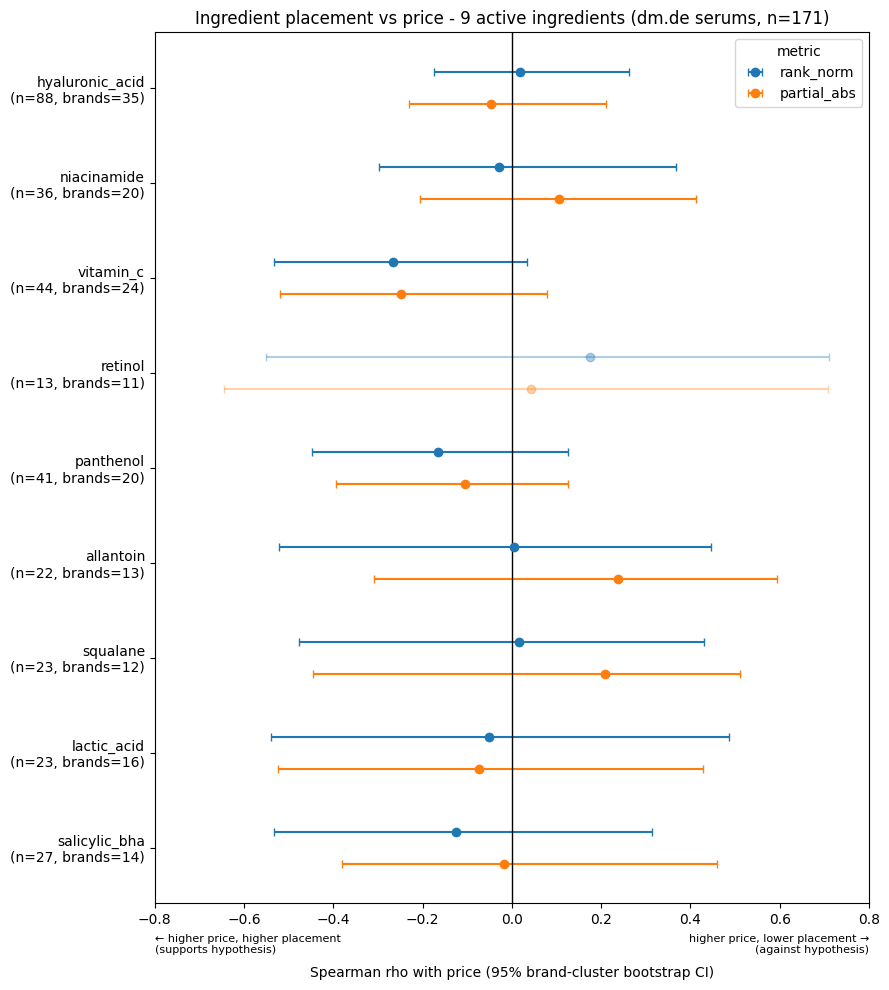

In [15]:
order = ["hyaluronic_acid", "niacinamide", "vitamin_c", "retinol",
         "panthenol", "allantoin", "squalane", "lactic_acid", "salicylic_bha"]
low_n_ings = {"retinol"}  # n=13で参考値扱い

colors = {"rank_norm": "#1f77b4", "partial_abs": "#ff7f0e"}
offset = {"rank_norm": -0.17, "partial_abs": 0.17}

fig, ax = plt.subplots(figsize=(9, 10))

for i, ing in enumerate(order):
    sub = fp[fp["ingredient"] == ing]
    for _, r in sub.iterrows():
        y = i + offset[r["metric"]]
        alpha = 0.35 if ing in low_n_ings else 1.0
        ax.errorbar(r["est"], y,
                    xerr=[[r["est"] - r["lo"]], [r["hi"] - r["est"]]],
                    fmt="o", color=colors[r["metric"]], alpha=alpha,
                    capsize=3, markersize=6,
                    label=r["metric"] if i == 0 else None)

ax.axvline(0, color="black", linewidth=1)
ax.set_yticks(range(len(order)))
labels = []
for ing in order:
    sub = fp[fp["ingredient"] == ing]
    n = sub["n"].iloc[0]
    nb_ = sub["n_brands"].iloc[0]
    labels.append(f"{ing}\n(n={n}, brands={nb_})")
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlim(-0.8, 0.8)
ax.set_xlabel("Spearman rho with price (95% brand-cluster bootstrap CI)", labelpad=28)
ax.text(0.0, -0.035, "\u2190 higher price, higher placement\n(supports hypothesis)",
        transform=ax.transAxes, fontsize=8, va="top", ha="left")
ax.text(1.0, -0.035, "higher price, lower placement \u2192\n(against hypothesis)",
        transform=ax.transAxes, fontsize=8, va="top", ha="right")
ax.set_title("Ingredient placement vs price - 9 active ingredients (dm.de serums, n=171)")
ax.legend(title="metric", loc="upper right")
plt.tight_layout()
plt.savefig("fig3_forest_all9.png", dpi=200)
plt.show()


### この図から言えること

- 9成分いずれも、区間は0の縦線をまたいでおり、**「高価格ほど有効成分を上位に配合している」**
  とはっきり言えるものはありませんでした。
- hyaluronic_acid(n=88)とvitamin_c(n=44)が最も区間が狭く、「中程度以上の関係はない」と
  最も自信を持って言えます。
- retinol(n=13)が最も区間が広く、このデータでは判断できません。
- rank_normとpartial_absの2指標で、横棒の位置がおおむね揃っており、**指標を変えても結論が
  変わらない**ことが視覚的に示されています(allantoin・squalaneでややズレが見られますが、
  区間の広さを考えると誤差の範囲内です)。


---
## Step 12: 総括と限界

### 分析Aの結論

**「高価格帯ほど、有効成分を成分表の上位に配合している」という仮説は、検証した9成分
いずれでも支持されませんでした。**

| 成分 | 結論 |
|---|---|
| ヒアルロン酸・ナイアシンアミド・乳酸 | rank_norm・偏相関ともにほぼ0で、安定して「関係なし」 |
| ビタミンC | 両指標で−0.25〜−0.27の弱い負の傾向。9成分中最も仮説に近いが、区間は0に届く |
| レチノール | n=13で判断不能 |
| パンテノール・サリチル酸系 | rank_normでは負の傾向があったが、偏相関ではほぼ消えた(成分数バイアスの影響) |
| アラントイン・スクアラン | 偏相関で正の値が出たが、信頼区間が広く判断できない |
| 頑健性 | 使い切り品の除外、ブランド単位の信頼区間、データ品質修正、いずれでも結論は変わらず |

### 方法論上の発見(副産物)

分析の過程で、当初の想定にはなかった重要な発見が2つありました。

- **`rank_norm`(順位÷成分数)という指標は、成分数そのものと価格の相関の影響を受けてしまう。**
  実際、基剤成分であるグリセリンで、この効果がはっきりと確認できました(Step 7)。
- 逆に絶対順位も「成分数が多いと後ろに押し出されやすい」という別の偏りを持ちます。
  **単一の指標に頼らず、複数の指標を突き合わせて確認することの重要性**が、この分析全体を
  通じての教訓です。

さらに、Step 4.5で行ったデータ品質検証も、この分析の副産物です。パイプライン側の
成分パース処理に**カンマを含むINCI名の分割崩れ(171件中41件に影響)**と
**見出し語「INGREDIENTS」の混入(171件中1件に影響)**という2つのバグを発見・修正
しましたが、**修正の前後で9成分すべての結論(信頼区間が0をまたぐかどうか)は変わりません
でした。** これは、Aの結論がデータの細かいノイズに左右されない、安定した発見であることを
裏付けています。

### この分析の限界

- **価格は容量(ml)を考慮していません。** 30mlで15€と15mlで15€は同列に扱われており、
  「単位量あたりの価格」ではない点に注意が必要です。
- **成分の順位は、濃度の完全な代理指標ではありません。** EUの表示規則上、
  濃度1%未満の成分は順不同でよいとされているため、有効成分の多くはこの規則の影響を受けます。
- **対象はdm.deの、ある時点の171商品です。** ドイツの美容液市場全体や、他の時点への一般化は
  できません。
- **偏相関は、成分数の影響を線形回帰で除いた簡易版です。** 非線形な関係が残っている
  可能性があります。
- **複数の成分・複数の指標を並べて検定しているため、多重比較の影響が完全には排除できません。**
  本分析では、個々のp値による判定ではなく、信頼区間を並べて見せる設計にすることで、
  この影響を抑えています。

### 次の分析へ

この後は、以下の分析に進む計画です。

- **B**: 香料・アルコール系溶媒の有無とratingの関係(Mann-Whitney U検定)
- **C**: PB(自社ブランド)とNBの配合順位比較。ブランド名から自社ブランドを機械的に判定できるため、
  30件の手動データより広い範囲で検証可能(詳細は別途)
- **D**: 成分数と価格の関係(本分析Step 7で一部先取り済み)
- **成分の訴求内容(concern)の自動抽出**: 商品説明文からのキーワード抽出、または軽量LLMによる分類


---
## Step 13: 補助分析 — 100mlあたり価格での頑健性チェック

Step 12の限界で述べたとおり、これまでの分析は`price_eur_clean`(商品の販売価格)を
そのまま使っており、**容量(ml)を考慮していません**。30mlで15€と15mlで15€では、
後者の方が実質2倍高いにもかかわらず、同じ「15€」として扱っていました。

そこで、Step 3で作成済みの`size_num`・`size_unit`を使い、**100mlあたり価格
(`price_per_100ml`)**に変換したうえで、Step 6・8・10と同じ分析を再実行します。
これは「価格の定義を置き換える」のではなく、**追加の頑健性チェック**として位置づけます。

ただし、単純な単価換算には注意点があります。使い切り品(アンプル・カプセル)は、
中身の質とは無関係にパッケージングコストの影響で単位量あたりの価格が高くなりがち
(スケールメリットの歪み)なためです。この点も検証しながら進めます。

### Step 13.1: price_per_100mlの計算

In [16]:
# 1) mlに統一した容量列を作る(St・g表記はNaNにする = per-100ml化できない)
df_a["size_ml"] = np.where(
    df_a["size_unit"] == "l", df_a["size_num"] * 1000,
    np.where(df_a["size_unit"] == "ml", df_a["size_num"], np.nan)
)

# 2) 100mlあたり価格を計算
df_a["price_per_100ml"] = df_a["price_eur_clean"] / df_a["size_ml"] * 100

# 3) 変換できた件数・できなかった件数を確認
print("price_per_100mlを計算できた件数:", df_a["price_per_100ml"].notna().sum())
print("計算できなかった件数(St・g表記):", df_a["price_per_100ml"].isna().sum())
print(df_a.loc[df_a["price_per_100ml"].isna(), ["name", "size_num", "size_unit"]])

# 4) 分布を確認
print(df_a["price_per_100ml"].describe())
print(df_a.groupby("single_use")["price_per_100ml"].describe())

# 5) 上位10件を確認(使い切り品に偏っていないか)
cols = ["name", "price_eur_clean", "size_ml", "price_per_100ml", "single_use"]
print(df_a.nlargest(10, "price_per_100ml")[cols])

price_per_100mlを計算できた件数: 160
計算できなかった件数(St・g表記): 11
                                         name  size_num size_unit
100        Konzentrat Perfect Skin Glow, 7 St       7.0        St
104        Konzentrat Kapseln Kollagen, 10 St      10.0        St
107          Konzentrat Vitamin C Power, 7 St       7.0        St
110           Serum Stick Lazy Day Hydro, 9 g       9.0         g
124                  Konzentrat Retinol, 7 St       7.0        St
127  Konzentrat Kapseln Anti-Falten Q10, 7 St       7.0        St
131         Augen und Lippen Konzentrat, 7 St       7.0        St
132                Konzentrat Vitamin C, 7 St       7.0        St
133                 Hyaluron Konzentrat, 7 St       7.0        St
148                 Konzentrat Anti-Age, 7 St       7.0        St
163                      Ampullen Lift+, 7 St       7.0        St
count    160.000000
mean      50.439564
std       32.781733
min        6.500000
25%       27.670455
50%       46.500000
75%       66.333333
max      266.964

### 結果(実測値)

160件(171件中)でprice_per_100mlを計算できました。計算できなかった11件は、
St(個数)表記10件・g(質量)表記1件で、いずれも使い切り品(アンプル・カプセル・
スティック)でした。

使い切り品(n=4、mlで容量が分かるもののみ)の平均単価は109.5€/100ml、通常品
(n=156)は48.9€/100mlと、**想定どおり使い切り品の方が単価は高め**でした。
しかし、単価が最も高い上位10件を見ると、**1位のみが使い切り品で、2位以降はすべて
通常のボトル品**(15〜30ml)でした。つまり、単価の高さは「使い切り品だから」ではなく、
**小容量・高価格帯のプレステージ系美容液の存在**によるものでした。この結果を踏まえ、
St/g表記の11件は除外した160件を対象に、以降の分析を進めます。

### Step 13.2: Spearman相関とブートストラップ信頼区間(price_per_100ml版)

In [17]:
rows = []
for ing in actives + ["glycerin"]:
    sub = df_a[(df_a[f"{ing}_present"] == 1) & (df_a["price_per_100ml"].notna())]
    rho, p = spearmanr(sub["price_per_100ml"], sub[f"{ing}_rank_norm"])
    lo, hi = boot_spearman(sub["price_per_100ml"].values, sub[f"{ing}_rank_norm"].values)
    rows.append({"ingredient": ing, "n": len(sub),
                 "rho": round(rho, 3), "p": round(p, 3),
                 "ci_low": round(lo, 3), "ci_high": round(hi, 3)})

result_per100ml = pd.DataFrame(rows)
print(result_per100ml)

        ingredient    n    rho      p  ci_low  ci_high
0  hyaluronic_acid   85 -0.117  0.285  -0.318    0.096
1      niacinamide   36  0.025  0.883  -0.321    0.368
2        vitamin_c   40 -0.370  0.019  -0.624   -0.079
3          retinol   13  0.055  0.858  -0.510    0.671
4        panthenol   40 -0.190  0.239  -0.475    0.136
5        allantoin   22  0.005  0.983  -0.427    0.418
6         squalane   17 -0.153  0.557  -0.652    0.425
7      lactic_acid   23  0.113  0.607  -0.372    0.538
8    salicylic_bha   26 -0.126  0.541  -0.532    0.317
9         glycerin  138 -0.240  0.005  -0.388   -0.079


### 結果(実測値): price_eur_cleanとの比較

| 成分 | n(価格) | rho(価格) | n(単価) | rho(単価) | 95%CI(単価) |
|---|---|---|---|---|---|
| hyaluronic_acid | 88 | 0.019 | 85 | −0.117 | −0.32 〜 +0.10 |
| niacinamide | 36 | −0.028 | 36 | 0.025 | −0.30 〜 +0.37 |
| **vitamin_c** | 44 | −0.266 | **40** | **−0.370** | **−0.62 〜 −0.03** |
| retinol | 13 | 0.176 | 13 | 0.055 | −0.51 〜 +0.65 |
| panthenol | 41 | −0.160 | 40 | −0.190 | −0.47 〜 +0.14 |
| allantoin | 22 | 0.005 | 22 | 0.005 | −0.41 〜 +0.42 |
| squalane | 23 | 0.017 | 17 | −0.153 | −0.64 〜 +0.41 |
| lactic_acid | 23 | −0.052 | 23 | 0.113 | −0.34 〜 +0.57 |
| salicylic_bha | 27 | −0.125 | 26 | −0.126 | −0.55 〜 +0.32 |
| glycerin(対照) | 140 | −0.288 | 138 | −0.240 | −0.40 〜 −0.08 |

単価ベースに変換すると、**ビタミンCが初めて商品単位の信頼区間で0をまたがなくなりました**
(rho=−0.370, 95%CI[−0.62, −0.03])。他の成分は符号が変わるものもありますが(ヒアルロン酸、
スクアラン、乳酸)、いずれも区間は広く、結論を変えるほどの根拠ではありません。

スクアランはSt表記の除外で n=23→17 と大きく減っており(配合商品がアンプル形態に
偏っていたため)、この成分の単価ベース結果は参考程度に留めます。

### Step 13.3: 偏相関(成分数を統制、price_per_100ml版)

In [18]:
for ing in actives + ["glycerin"]:
    sub = df_a[(df_a[f"{ing}_present"] == 1) & (df_a["price_per_100ml"].notna())]
    pr = partial_spearman(sub["price_per_100ml"], sub[f"{ing}_rank"], sub["ingredient_count"])
    print(ing, "partial rho (rank | ingredient_count, price_per_100ml):", round(pr, 3))

hyaluronic_acid partial rho (rank | ingredient_count, price_per_100ml): -0.143
niacinamide partial rho (rank | ingredient_count, price_per_100ml): 0.108
vitamin_c partial rho (rank | ingredient_count, price_per_100ml): -0.382
retinol partial rho (rank | ingredient_count, price_per_100ml): -0.013
panthenol partial rho (rank | ingredient_count, price_per_100ml): -0.054
allantoin partial rho (rank | ingredient_count, price_per_100ml): 0.26
squalane partial rho (rank | ingredient_count, price_per_100ml): -0.086
lactic_acid partial rho (rank | ingredient_count, price_per_100ml): 0.027
salicylic_bha partial rho (rank | ingredient_count, price_per_100ml): 0.032
glycerin partial rho (rank | ingredient_count, price_per_100ml): -0.1


### 結果(実測値)

| 成分 | 偏相関(価格) | 偏相関(単価) |
|---|---|---|
| hyaluronic_acid | −0.047 | −0.143 |
| niacinamide | 0.105 | 0.108 |
| **vitamin_c** | −0.248 | **−0.382** |
| retinol | 0.042 | −0.013 |
| panthenol | −0.102 | −0.054 |
| allantoin | 0.237 | 0.260 |
| squalane | 0.208 | −0.086 |
| lactic_acid | −0.073 | 0.027 |
| salicylic_bha | −0.017 | 0.032 |
| glycerin(対照) | −0.073 | −0.100 |

**ビタミンCは、rank_norm・偏相関の両方で、単価ベースにすると一貫して強まりました。**
成分数バイアスの産物ではなく、より本物らしい関係であることが示唆されます。

### Step 13.4: ブランド単位のクラスタ・ブートストラップ(price_per_100ml版)

In [19]:
def corr_norm_p100(d, ing):
    r, _ = spearmanr(d["price_per_100ml"], d[f"{ing}_rank_norm"])
    return r

def corr_partial_p100(d, ing):
    return partial_spearman(d["price_per_100ml"], d[f"{ing}_rank"], d["ingredient_count"])

rows2 = []
for ing in actives + ["glycerin"]:
    sub = df_a[(df_a[f"{ing}_present"] == 1) & (df_a["price_per_100ml"].notna())]
    for func, name in [(corr_norm_p100, "rank_norm"), (corr_partial_p100, "partial_abs")]:
        est = func(sub, ing)
        lo, hi = cluster_boot_ing(sub, ing, func)
        rows2.append({"ingredient": ing, "metric": name, "n": len(sub),
                     "n_brands": sub["brand"].nunique(),
                     "est": round(est, 3), "lo": round(lo, 3), "hi": round(hi, 3)})

fp_per100ml = pd.DataFrame(rows2)
print(fp_per100ml)

         ingredient       metric    n  n_brands    est     lo     hi
0   hyaluronic_acid    rank_norm   85        35 -0.117 -0.342  0.147
1   hyaluronic_acid  partial_abs   85        35 -0.143 -0.354  0.161
2       niacinamide    rank_norm   36        20  0.025 -0.295  0.398
3       niacinamide  partial_abs   36        20  0.108 -0.227  0.457
4         vitamin_c    rank_norm   40        21 -0.370 -0.615 -0.028
5         vitamin_c  partial_abs   40        21 -0.382 -0.619 -0.043
6           retinol    rank_norm   13        11  0.055 -0.501  0.653
7           retinol  partial_abs   13        11 -0.013 -0.598  0.564
8         panthenol    rank_norm   40        20 -0.190 -0.507  0.161
9         panthenol  partial_abs   40        20 -0.054 -0.372  0.198
10        allantoin    rank_norm   22        13  0.005 -0.412  0.404
11        allantoin  partial_abs   22        13  0.260 -0.194  0.645
12         squalane    rank_norm   17        11 -0.153 -0.609  0.293
13         squalane  partial_abs  

### 結果(実測値)

| 成分 | 指標 | n | n_brands | 推定値 | 95%CI |
|---|---|---|---|---|---|
| hyaluronic_acid | rank_norm | 85 | 35 | −0.117 | −0.34 〜 +0.15 |
| hyaluronic_acid | partial_abs | 85 | 35 | −0.143 | −0.35 〜 +0.16 |
| niacinamide | rank_norm | 36 | 20 | 0.025 | −0.30 〜 +0.40 |
| niacinamide | partial_abs | 36 | 20 | 0.108 | −0.23 〜 +0.46 |
| **vitamin_c** | **rank_norm** | 40 | 21 | **−0.370** | **−0.62 〜 −0.03** |
| **vitamin_c** | **partial_abs** | 40 | 21 | **−0.382** | **−0.62 〜 −0.04** |
| retinol | rank_norm | 13 | 11 | 0.055 | −0.50 〜 +0.65 |
| retinol | partial_abs | 13 | 11 | −0.013 | −0.60 〜 +0.56 |
| panthenol | rank_norm | 40 | 20 | −0.190 | −0.51 〜 +0.16 |
| panthenol | partial_abs | 40 | 20 | −0.054 | −0.37 〜 +0.20 |
| allantoin | rank_norm | 22 | 13 | 0.005 | −0.41 〜 +0.40 |
| allantoin | partial_abs | 22 | 13 | 0.260 | −0.19 〜 +0.65 |
| squalane | rank_norm | 17 | 11 | −0.153 | −0.61 〜 +0.29 |
| squalane | partial_abs | 17 | 11 | −0.086 | −0.55 〜 +0.45 |
| lactic_acid | rank_norm | 23 | 16 | 0.113 | −0.55 〜 +0.64 |
| lactic_acid | partial_abs | 23 | 16 | 0.027 | −0.52 〜 +0.48 |
| salicylic_bha | rank_norm | 26 | 14 | −0.126 | −0.55 〜 +0.35 |
| salicylic_bha | partial_abs | 26 | 14 | 0.032 | −0.47 〜 +0.55 |
| glycerin(対照) | rank_norm | 138 | 42 | −0.240 | −0.41 〜 −0.02 |
| glycerin(対照) | partial_abs | 138 | 42 | −0.100 | −0.33 〜 +0.12 |

**ビタミンCは、9成分+対照1成分の中で唯一、rank_norm・偏相関の両方でブランドクラスタ
信頼区間が0をまたぎませんでした。** 対照のグリセリンは、これまでと同じく
「rank_normのみ有意、偏相関では消える」という成分数バイアスのパターンを示しており、
ビタミンCの結果が質的に異なることの裏付けになっています。

### Step 13.5: ビタミンCの追加検証(外れ値・ブランド依存)

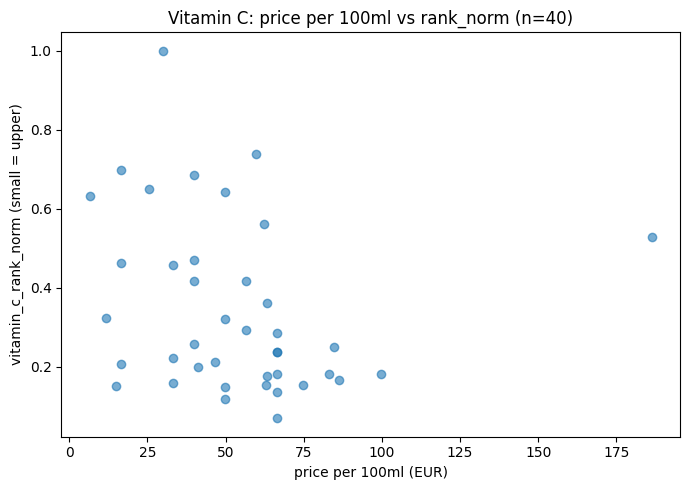

     artikelnummer               brand  \
106        1535263  Spilanthox therapy   

                                           name  price_per_100ml  \
106  Serum High-Potency Facelift Booster, 15 ml       186.333333   

     vitamin_c_rank_norm  
106             0.529412  
このブランドの商品数: 1
外れ値除外後: -0.434 0.006 -0.649 -0.112 | n = 39
L'Oréal系も除外後: -0.324 0.08 -0.613 0.025 | n = 30


In [20]:
sub_vc = df_a[(df_a["vitamin_c_present"] == 1) & (df_a["price_per_100ml"].notna())]

# 散布図で外れ値を確認
plt.figure(figsize=(7, 5))
plt.scatter(sub_vc["price_per_100ml"], sub_vc["vitamin_c_rank_norm"], alpha=0.6)
plt.xlabel("price per 100ml (EUR)")
plt.ylabel("vitamin_c_rank_norm (small = upper)")
plt.title(f"Vitamin C: price per 100ml vs rank_norm (n={len(sub_vc)})")
plt.tight_layout()
plt.savefig("fig5_vitamin_c_per100ml.png", dpi=150)
plt.show()

# 1) 最高単価の外れ値(1商品のみの孤立ブランド)を除外
outlier = sub_vc.nlargest(1, "price_per_100ml")
print(outlier[["artikelnummer", "brand", "name", "price_per_100ml", "vitamin_c_rank_norm"]])
print("このブランドの商品数:", (df_a["brand"] == outlier["brand"].iloc[0]).sum())

sub_vc_no_outlier = sub_vc[sub_vc["price_per_100ml"] < 150]
rho_excl, p_excl = spearmanr(sub_vc_no_outlier["price_per_100ml"], sub_vc_no_outlier["vitamin_c_rank_norm"])
lo_excl, hi_excl = cluster_boot_ing(sub_vc_no_outlier, "vitamin_c", corr_norm_p100)
print("外れ値除外後:", round(rho_excl, 3), round(p_excl, 3), round(lo_excl, 3), round(hi_excl, 3), "| n =", len(sub_vc_no_outlier))

# 2) L'Oréal系(本体+REVITALIFT)も除外
loreal_mask = sub_vc_no_outlier["brand"].str.contains("L'ORÉAL", na=False)
sub_no_loreal = sub_vc_no_outlier[~loreal_mask]
rho_nl, p_nl = spearmanr(sub_no_loreal["price_per_100ml"], sub_no_loreal["vitamin_c_rank_norm"])
lo_nl, hi_nl = boot_spearman(sub_no_loreal["price_per_100ml"].values, sub_no_loreal["vitamin_c_rank_norm"].values)
print("L'Oréal系も除外後:", round(rho_nl, 3), round(p_nl, 3), round(lo_nl, 3), round(hi_nl, 3), "| n =", len(sub_no_loreal))

### 結果(実測値): ビタミンCの発見は、どこまで頑健か

| チェック | n | rho | p | 95%CI | 0をまたぐか |
|---|---|---|---|---|---|
| ① 全体(外れ値含む) | 40 | −0.370 | 0.019 | −0.62 〜 −0.03 | またがない |
| ② 外れ値1点(Spilanthox therapy, 186€/100ml)を除外 | 39 | −0.434 | 0.006 | −0.66 〜 −0.14 | またがない |
| ③ ②+L'Oréal系9件(本体+REVITALIFT)も除外 | 30 | −0.324 | 0.080 | −0.61 〜 +0.03 | **またぐ(ぎりぎり)** |

**外れ値1点の除外では、むしろ相関が強まりました。** これは外れ値が結果を作っていたのではなく、
逆に相関を弱める方向に働いていたことを意味し、安心材料です。

一方、**L'Oréal系9件(全体の23%)を除くと、信頼区間がわずかに0をまたぎます。** これは、
ビタミンCの負の相関が「業界全体に共通する傾向」というより、**L'Oréal系ブランドの処方・
価格戦略に牽引されている可能性が高い**ことを示しています。

### 結論: ビタミンCの発見は「示唆的」であり、「確定的」ではない

- 全データでは、単価とビタミンCの配合順位に、統計的に有意な負の相関が見られた
- 外れ値の影響ではなく、方向性は一貫している
- ただし、**この関係は特定ブランド(L'Oréal系)に強く依存しており**、業界全体への
  一般化はできない
- 「価格帯が高いほどビタミンCを上位配合する」という一般則というより、**「L'Oréalは、
  単価の高いラインほどビタミンCを上位配合する傾向がある」という、ブランド単位の
  観察**と捉えるのがより正確

これはAの本編(Step 9〜10)で確立した方法論(最大ブランドBaleaを除いても結果が
変わらないかを確認する)と同じ精神のチェックであり、本編の9成分とは異なる形で
「ブランド依存」という限界が見つかった、という位置づけになります。

### Step 13の結論

100mlあたり価格への変換は、Step 12までの主結論(9成分いずれも仮説を支持する
確度の高い証拠はない)を覆すものではありませんでした。一方で、唯一ビタミンCについて、
単価ベースでは統計的に有意な負の相関が見られるという、新たな手がかりが得られました。
ただし、この関係はL'Oréal系ブランドへの依存度が高く、**「業界全体の傾向」ではなく
「一部ブランドに見られる戦略」として慎重に解釈すべき**です。

**この分析の追加の限界**

- St/g表記の11商品(使い切り品が中心)は、単価換算できず除外されている
- スクアランは、単価換算可能なサンプルが使い切り品除外で23→17件に減少しており、
  他の成分より結果の信頼性が低い
- ビタミンCの発見は、ブランド依存性が高く、L'Oréal系を除くと統計的な確度を失う